🔬 StarDist3D Training Analysis - Thesis Quality Plots

📖 Reading training log: C:\Users\OSVALDO\Downloads\stardist3Dtrain.txt

STARDIST3D TRAINING SUMMARY

📊 Training Configuration:
  Total Volumes:         24 (20 training, 4 validation)
  Patch Size:            32×128×128 (Z×Y×X)
  Batch Size:            2
  Steps per Epoch:       100
  Patches per Epoch:     200
  Total Epochs:          21
  Total Patches Trained: 4,200
  Learning Rate:         3×10⁻⁴ (constant)
  Anisotropy:            2.7:1:1 (Z:Y:X)

🎯 FINAL METRICS (Epoch 21):
  Training Loss:         0.8145
  Validation Loss:       0.7822
  Training IoU:          0.5821
  Validation IoU:        0.5604

📈 BEST METRICS:
  Best Training Loss:    0.8145 (Epoch 21)
  Best Validation Loss:  0.7810 (Epoch 20)
  Best Validation IoU:   0.5638 (Epoch 20)

📉 IMPROVEMENT FROM EPOCH 1:
  Validation Loss:       1.690 → 0.782 (+53.7%)
  Validation IoU:        0.198 → 0.560 (+183.3%)
  Distance Loss:         7.016 → 2.735 (+61.0%)

🔍 GENERALIZA

C:\Users\OSVALDO\AppData\Local\Temp\ipykernel_7172\2567568263.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Loss curve saved: Figure_LossCurve.png

3. Single IoU curve (performance metric)
✓ IoU curve saved: Figure_IoU.png

✅ Analysis complete! Generated 3 publication-ready figures.

📁 Output files:
   • Figure_TrainingConvergence.png (4-panel, 300 DPI)
   • Figure_LossCurve.png (single plot, 300 DPI)
   • Figure_IoU.png (single plot, 300 DPI)

💡 All figures use:
   • DejaVu Sans font (matching your thesis)
   • Blue (#1f77b4) for Training
   • Orange (#ff7f0e) for Validation
   • High resolution (300 DPI) for publication
   • Clean, professional style


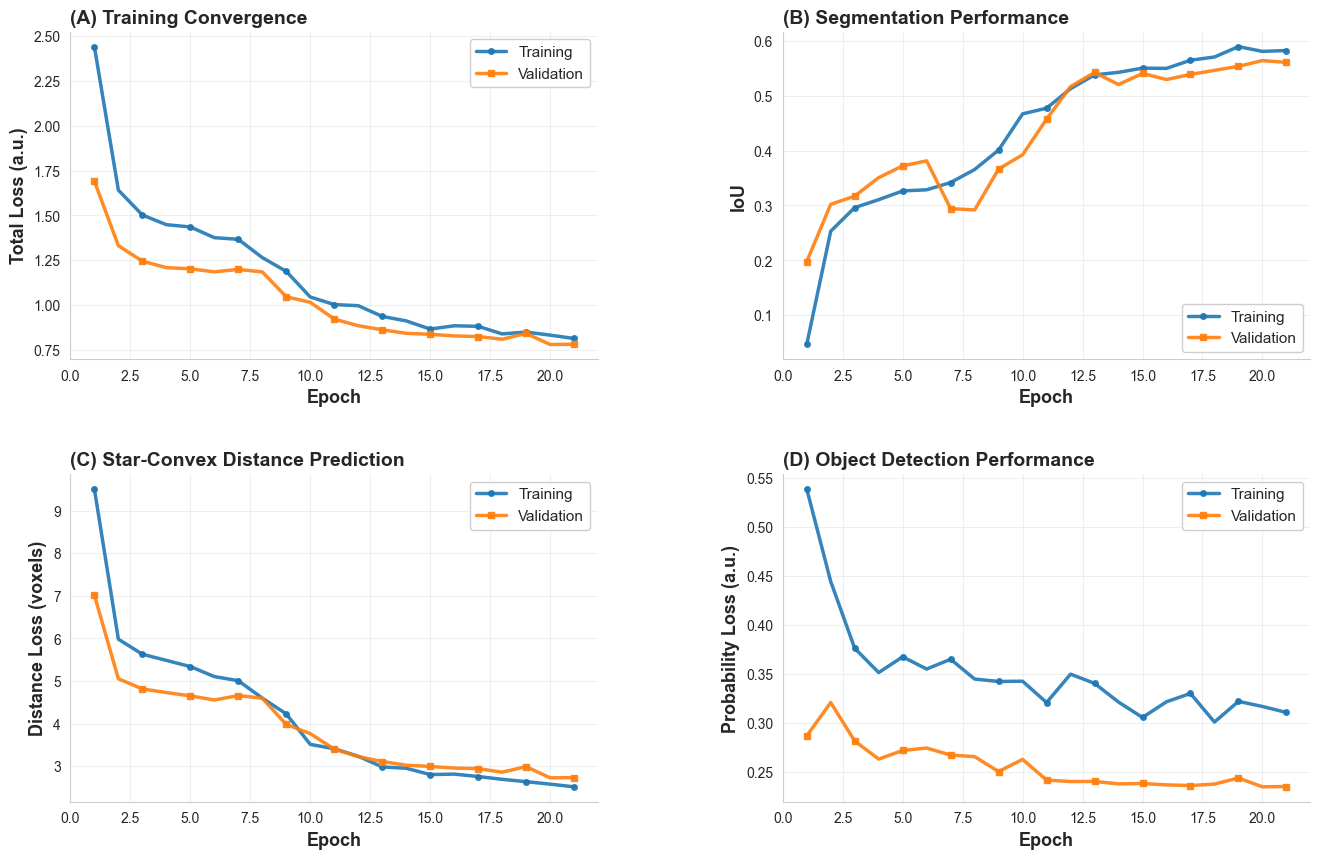

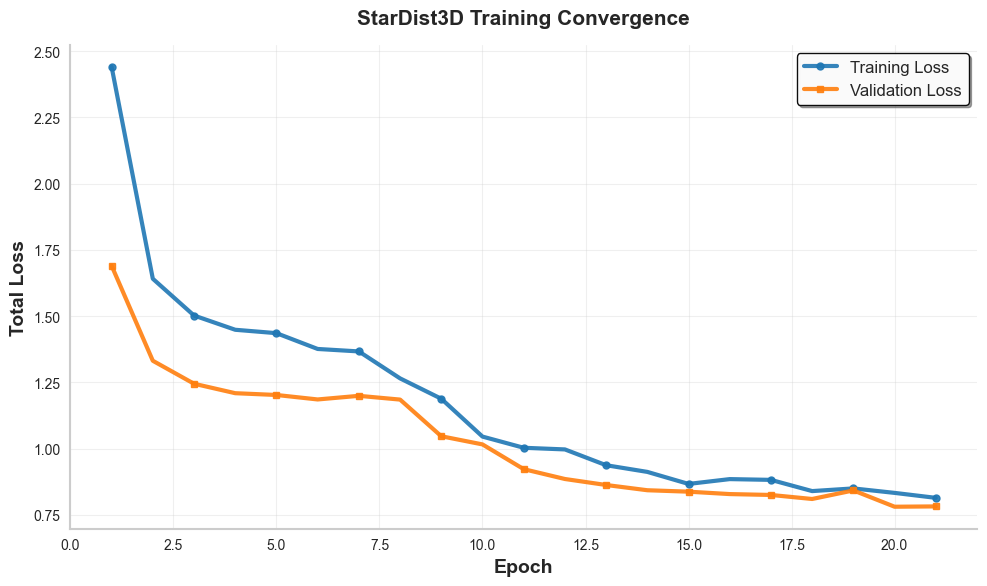

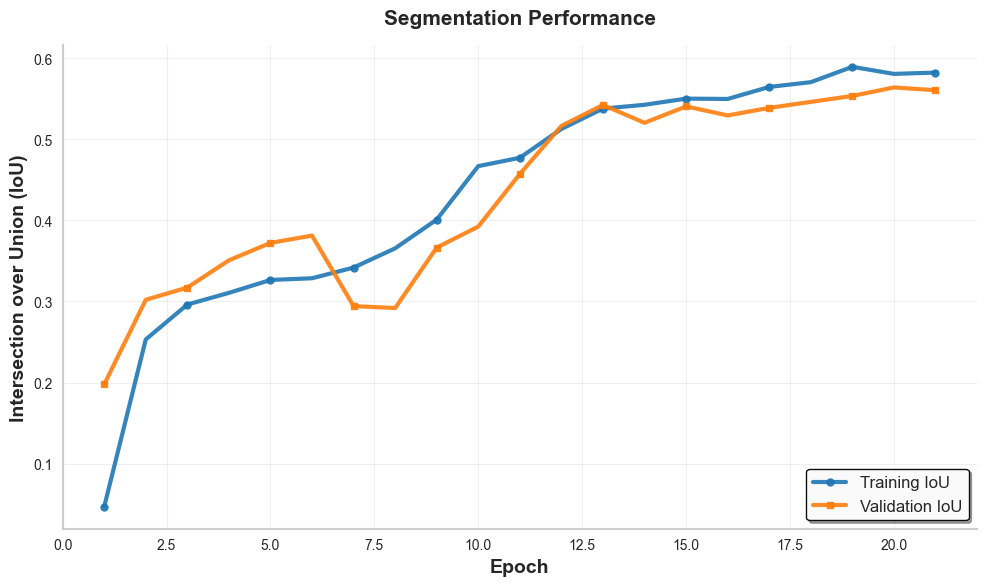

In [7]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Configure plot style for thesis - DejaVu Sans font
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.8

# Thesis color scheme - Blue and Orange
COLOR_TRAIN = '#1f77b4'  # Professional blue
COLOR_VAL = '#ff7f0e'    # Professional orange
COLOR_LR = '#2ca02c'     # Green for learning rate
COLOR_GAP = '#9467bd'    # Purple for gap analysis

sns.set_style("whitegrid")

def parse_training_log(log_file_path):
    """
    Parse StarDist3D training log file to extract metrics
    """
    epochs = []
    train_loss = []
    train_prob_loss = []
    train_dist_loss = []
    train_iou = []
    
    val_loss = []
    val_prob_loss = []
    val_dist_loss = []
    val_iou = []
    
    learning_rates = []
    
    # Read log file
    with open(log_file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Extract epoch information using regex
    epoch_pattern = r'Epoch (\d+)/\d+'
    epochs_found = re.findall(epoch_pattern, content)
    
    # Extract training metrics (final values of each epoch)
    train_pattern = r'100/100.*?loss: ([\d.]+).*?prob_loss: ([\d.]+).*?dist_loss: ([\d.]+).*?dist_dist_iou_metric: ([\d.]+)'
    train_matches = re.findall(train_pattern, content)
    
    # Extract validation metrics
    val_pattern = r'val_loss: ([\d.]+).*?val_prob_loss: ([\d.]+).*?val_dist_loss: ([\d.]+).*?val_dist_dist_iou_metric: ([\d.]+)'
    val_matches = re.findall(val_pattern, content)
    
    # Extract learning rates
    lr_pattern = r'lr: ([\d.e-]+)'
    lr_matches = re.findall(lr_pattern, content)
    
    # Process matches
    for i, (tl, tpl, tdl, tiou) in enumerate(train_matches):
        epochs.append(i + 1)
        train_loss.append(float(tl))
        train_prob_loss.append(float(tpl))
        train_dist_loss.append(float(tdl))
        train_iou.append(float(tiou))
    
    for vl, vpl, vdl, viou in val_matches:
        val_loss.append(float(vl))
        val_prob_loss.append(float(vpl))
        val_dist_loss.append(float(vdl))
        val_iou.append(float(viou))
    
    for lr in lr_matches:
        learning_rates.append(float(lr))
    
    return {
        'epochs': np.array(epochs),
        'train_loss': np.array(train_loss),
        'train_prob_loss': np.array(train_prob_loss),
        'train_dist_loss': np.array(train_dist_loss),
        'train_iou': np.array(train_iou),
        'val_loss': np.array(val_loss),
        'val_prob_loss': np.array(val_prob_loss),
        'val_dist_loss': np.array(val_dist_loss),
        'val_iou': np.array(val_iou),
        'learning_rate': np.array(learning_rates)
    }

def plot_training_convergence(metrics, save_path=None):
    """
    Create publication-quality training convergence plots for thesis
    """
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.35)
    
    epochs = metrics['epochs']
    
    # 1. Total Loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, metrics['train_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax1.plot(epochs, metrics['val_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Total Loss (a.u.)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax1.set_title('(A) Training Convergence', fontsize=14, fontweight='bold', loc='left')
    ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax1.grid(True, alpha=0.3, linewidth=0.8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # 2. IoU Metric
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, metrics['train_iou'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax2.plot(epochs, metrics['val_iou'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax2.set_ylabel('IoU', fontsize=13, fontweight='bold')  # IoU é adimensional
    ax2.set_title('(B) Segmentation Performance', fontsize=14, fontweight='bold', loc='left')
    ax2.legend(loc='lower right', fontsize=11, framealpha=0.95)
    ax2.grid(True, alpha=0.3, linewidth=0.8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 3. Distance Loss
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, metrics['train_dist_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax3.plot(epochs, metrics['val_dist_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax3.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Distance Loss (voxels)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax3.set_title('(C) Star-Convex Distance Prediction', fontsize=14, fontweight='bold', loc='left')
    ax3.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax3.grid(True, alpha=0.3, linewidth=0.8)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # 4. Probability Loss
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, metrics['train_prob_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax4.plot(epochs, metrics['val_prob_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax4.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Probability Loss (a.u.)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax4.set_title('(D) Object Detection Performance', fontsize=14, fontweight='bold', loc='left')
    ax4.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax4.grid(True, alpha=0.3, linewidth=0.8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figure saved: {save_path}")
    
    plt.tight_layout()
    return fig

def plot_single_loss_curve(metrics, save_path=None):
    """
    Create single publication-quality loss curve for thesis
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    epochs = metrics['epochs']
    
    ax.plot(epochs, metrics['train_loss'], color=COLOR_TRAIN, linewidth=3, 
            label='Training Loss', marker='o', markersize=5, markevery=2, alpha=0.9)
    ax.plot(epochs, metrics['val_loss'], color=COLOR_VAL, linewidth=3, 
            label='Validation Loss', marker='s', markersize=5, markevery=2, alpha=0.9)
    
    ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
    ax.set_ylabel('Total Loss', fontsize=14, fontweight='bold')
    ax.set_title('StarDist3D Training Convergence', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='upper right', fontsize=12, framealpha=0.95, edgecolor='black', shadow=True)
    ax.grid(True, alpha=0.3, linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Loss curve saved: {save_path}")
    
    plt.tight_layout()
    return fig

def plot_iou_curve(metrics, save_path=None):
    """
    Create single IoU metric plot for thesis
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    epochs = metrics['epochs']
    
    ax.plot(epochs, metrics['train_iou'], color=COLOR_TRAIN, linewidth=3, 
            label='Training IoU', marker='o', markersize=5, markevery=2, alpha=0.9)
    ax.plot(epochs, metrics['val_iou'], color=COLOR_VAL, linewidth=3, 
            label='Validation IoU', marker='s', markersize=5, markevery=2, alpha=0.9)
    
    ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intersection over Union (IoU)', fontsize=14, fontweight='bold')
    ax.set_title('Segmentation Performance', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95, edgecolor='black', shadow=True)
    ax.grid(True, alpha=0.3, linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ IoU curve saved: {save_path}")
    
    plt.tight_layout()
    return fig

def print_training_summary(metrics):
    """
    Print summary statistics of training
    """
    print("\n" + "="*70)
    print("STARDIST3D TRAINING SUMMARY")
    print("="*70)
    
    total_epochs = len(metrics['epochs'])
    total_patches = total_epochs * 100 * 2  # 100 steps/epoch × 2 batch size
    
    print(f"\n📊 Training Configuration:")
    print(f"  Total Volumes:         24 (20 training, 4 validation)")
    print(f"  Patch Size:            32×128×128 (Z×Y×X)")
    print(f"  Batch Size:            2")
    print(f"  Steps per Epoch:       100")
    print(f"  Patches per Epoch:     200")
    print(f"  Total Epochs:          {total_epochs}")
    print(f"  Total Patches Trained: {total_patches:,}")
    print(f"  Learning Rate:         3×10⁻⁴ (constant)")
    print(f"  Anisotropy:            2.7:1:1 (Z:Y:X)")
    
    print("\n🎯 FINAL METRICS (Epoch {}):" .format(total_epochs))
    print(f"  Training Loss:         {metrics['train_loss'][-1]:.4f}")
    print(f"  Validation Loss:       {metrics['val_loss'][-1]:.4f}")
    print(f"  Training IoU:          {metrics['train_iou'][-1]:.4f}")
    print(f"  Validation IoU:        {metrics['val_iou'][-1]:.4f}")
    
    print("\n📈 BEST METRICS:")
    best_train_idx = np.argmin(metrics['train_loss'])
    best_val_idx = np.argmin(metrics['val_loss'])
    best_iou_idx = np.argmax(metrics['val_iou'])
    
    print(f"  Best Training Loss:    {metrics['train_loss'][best_train_idx]:.4f} (Epoch {metrics['epochs'][best_train_idx]})")
    print(f"  Best Validation Loss:  {metrics['val_loss'][best_val_idx]:.4f} (Epoch {metrics['epochs'][best_val_idx]})")
    print(f"  Best Validation IoU:   {metrics['val_iou'][best_iou_idx]:.4f} (Epoch {metrics['epochs'][best_iou_idx]})")
    
    print("\n📉 IMPROVEMENT FROM EPOCH 1:")
    initial_val_loss = metrics['val_loss'][0]
    final_val_loss = metrics['val_loss'][-1]
    loss_reduction = ((initial_val_loss - final_val_loss) / initial_val_loss) * 100
    
    initial_val_iou = metrics['val_iou'][0]
    final_val_iou = metrics['val_iou'][-1]
    iou_improvement = ((final_val_iou - initial_val_iou) / initial_val_iou) * 100
    
    initial_dist = metrics['val_dist_loss'][0]
    final_dist = metrics['val_dist_loss'][-1]
    dist_reduction = ((initial_dist - final_dist) / initial_dist) * 100
    
    print(f"  Validation Loss:       {initial_val_loss:.3f} → {final_val_loss:.3f} ({loss_reduction:+.1f}%)")
    print(f"  Validation IoU:        {initial_val_iou:.3f} → {final_val_iou:.3f} ({iou_improvement:+.1f}%)")
    print(f"  Distance Loss:         {initial_dist:.3f} → {final_dist:.3f} ({dist_reduction:+.1f}%)")
    
    print("\n🔍 GENERALIZATION ANALYSIS:")
    loss_gap = metrics['val_loss'][-1] - metrics['train_loss'][-1]
    
    if loss_gap < 0:
        status = "✓ Excellent - Validation better than training"
        interpretation = "The model generalizes well to unseen data."
    elif loss_gap < 0.05:
        status = "✓ Excellent - Minimal overfitting"
        interpretation = "Strong generalization capability."
    elif loss_gap < 0.15:
        status = "✓ Good - Slight overfitting"
        interpretation = "Acceptable generalization performance."
    elif loss_gap < 0.3:
        status = "⚠ Moderate overfitting"
        interpretation = "Consider regularization or more training data."
    else:
        status = "⚠ Significant overfitting"
        interpretation = "Model may not generalize well to new data."
    
    print(f"  Train-Val Loss Gap:    {loss_gap:.4f}")
    print(f"  Status:                {status}")
    print(f"  Interpretation:        {interpretation}")
    
    print("\n" + "="*70 + "\n")

# EXAMPLE USAGE
if __name__ == "__main__":
    
    print("🔬 StarDist3D Training Analysis - Thesis Quality Plots")
    print("="*70)
    
    # Path to your training log file
    log_file = r"C:\Users\OSVALDO\Downloads\stardist3Dtrain.txt"  # CHANGE THIS to your log file path
    
    # Parse the training log
    print(f"\n📖 Reading training log: {log_file}")
    metrics = parse_training_log(log_file)
    
    # Print comprehensive summary
    print_training_summary(metrics)
    
    # Generate thesis-quality plots
    print("📊 Generating publication-quality plots...")
    print("\n1. Complete 4-panel figure (main results)")
    plot_training_convergence(metrics, save_path='Figure_TrainingConvergence.png')
    
    print("\n2. Single loss curve (for simple presentation)")
    plot_single_loss_curve(metrics, save_path='Figure_LossCurve.png')
    
    print("\n3. Single IoU curve (performance metric)")
    plot_iou_curve(metrics, save_path='Figure_IoU.png')
    
    print("\n" + "="*70)
    print("✅ Analysis complete! Generated 3 publication-ready figures.")
    print("\n📁 Output files:")
    print("   • Figure_TrainingConvergence.png (4-panel, 300 DPI)")
    print("   • Figure_LossCurve.png (single plot, 300 DPI)")
    print("   • Figure_IoU.png (single plot, 300 DPI)")
    print("\n💡 All figures use:")
    print("   • DejaVu Sans font (matching your thesis)")
    print("   • Blue (#1f77b4) for Training")
    print("   • Orange (#ff7f0e) for Validation")
    print("   • High resolution (300 DPI) for publication")
    print("   • Clean, professional style")

In [6]:
def plot_training_convergence(metrics, save_path=None):
    """
    Create publication-quality training convergence plots for thesis
    """
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.35)
    
    epochs = metrics['epochs']
    
    # 1. Total Loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, metrics['train_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax1.plot(epochs, metrics['val_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Total Loss (a.u.)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax1.set_title('(A) Training Convergence', fontsize=14, fontweight='bold', loc='left')
    ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax1.grid(True, alpha=0.3, linewidth=0.8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # 2. IoU Metric
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, metrics['train_iou'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax2.plot(epochs, metrics['val_iou'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax2.set_ylabel('IoU', fontsize=13, fontweight='bold')  # IoU é adimensional
    ax2.set_title('(B) Segmentation Performance', fontsize=14, fontweight='bold', loc='left')
    ax2.legend(loc='lower right', fontsize=11, framealpha=0.95)
    ax2.grid(True, alpha=0.3, linewidth=0.8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 3. Distance Loss
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, metrics['train_dist_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax3.plot(epochs, metrics['val_dist_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax3.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Distance Loss (voxels)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax3.set_title('(C) Star-Convex Distance Prediction', fontsize=14, fontweight='bold', loc='left')
    ax3.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax3.grid(True, alpha=0.3, linewidth=0.8)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # 4. Probability Loss
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, metrics['train_prob_loss'], color=COLOR_TRAIN, linewidth=2.5, 
             label='Training', marker='o', markersize=4, markevery=2, alpha=0.9)
    ax4.plot(epochs, metrics['val_prob_loss'], color=COLOR_VAL, linewidth=2.5, 
             label='Validation', marker='s', markersize=4, markevery=2, alpha=0.9)
    ax4.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Probability Loss (a.u.)', fontsize=13, fontweight='bold')  # UNIDADE ADICIONADA
    ax4.set_title('(D) Object Detection Performance', fontsize=14, fontweight='bold', loc='left')
    ax4.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax4.grid(True, alpha=0.3, linewidth=0.8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figure saved: {save_path}")
    
    plt.tight_layout()
    return fig

In [9]:
import numpy as np
from tifffile import imread
import napari
from skimage.measure import label, regionprops
import pandas as pd

def count_individual_masks(mask_file):
    """
    Count individual masks in a label/mask image from Napari
    
    Parameters:
    -----------
    mask_file : str
        Path to the mask TIF file
        
    Returns:
    --------
    int : Number of individual masks
    dict : Dictionary with detailed information
    """
    
    print(f"📖 Reading mask file: {mask_file}")
    
    # Load the mask
    masks = imread(mask_file)
    
    print(f"✓ Mask loaded successfully")
    print(f"  Shape: {masks.shape}")
    print(f"  Dtype: {masks.dtype}")
    print(f"  Dimensions: {len(masks.shape)}D")
    
    # Get unique labels (excluding background = 0)
    unique_labels = np.unique(masks)
    unique_labels = unique_labels[unique_labels != 0]  # Remove background
    
    n_masks = len(unique_labels)
    
    print(f"\n🎯 MASK ANALYSIS:")
    print(f"  Total individual masks: {n_masks}")
    print(f"  Label range: {unique_labels.min()} to {unique_labels.max()}")
    print(f"  Background pixels: {np.sum(masks == 0):,}")
    print(f"  Labeled pixels: {np.sum(masks > 0):,}")
    
    # Additional statistics
    results = {
        'n_masks': n_masks,
        'unique_labels': unique_labels.tolist(),
        'shape': masks.shape,
        'min_label': int(unique_labels.min()) if n_masks > 0 else 0,
        'max_label': int(unique_labels.max()) if n_masks > 0 else 0,
        'background_pixels': int(np.sum(masks == 0)),
        'labeled_pixels': int(np.sum(masks > 0))
    }
    
    return n_masks, results


def analyze_mask_properties(mask_file, visualize=False):
    """
    Detailed analysis of individual masks with size and properties
    
    Parameters:
    -----------
    mask_file : str
        Path to the mask TIF file
    visualize : bool
        If True, open in napari for visualization
        
    Returns:
    --------
    pd.DataFrame : Properties of each individual mask
    """
    
    print(f"📖 Reading and analyzing: {mask_file}")
    
    # Load masks
    masks = imread(mask_file)
    
    # Ensure masks are labeled (connected components)
    # If your masks are already labeled from Napari, this won't change them
    # If they're binary, this will label connected components
    if masks.max() == 1:
        print("⚠️  Detected binary mask - labeling connected components...")
        masks_labeled = label(masks)
    else:
        masks_labeled = masks
    
    # Get region properties
    print("🔍 Extracting mask properties...")
    props = regionprops(masks_labeled)
    
    # Create DataFrame with properties
    data = []
    for prop in props:
        data.append({
            'label': prop.label,
            'area': prop.area,
            'centroid_z': prop.centroid[0] if len(prop.centroid) == 3 else None,
            'centroid_y': prop.centroid[-2],
            'centroid_x': prop.centroid[-1],
            'bbox_volume': prop.area_bbox if len(masks.shape) == 3 else None,
            'equivalent_diameter': prop.equivalent_diameter_area,
            'solidity': prop.solidity,
        })
    
    df = pd.DataFrame(data)
    
    # Print summary
    print(f"\n📊 MASK PROPERTIES SUMMARY:")
    print(f"  Total masks: {len(df)}")
    print(f"\n  Size statistics (in voxels/pixels):")
    print(f"    Mean area: {df['area'].mean():.1f}")
    print(f"    Median area: {df['area'].median():.1f}")
    print(f"    Min area: {df['area'].min():.0f}")
    print(f"    Max area: {df['area'].max():.0f}")
    print(f"    Std area: {df['area'].std():.1f}")
    
    # Visualize if requested
    if visualize:
        print(f"\n👁️  Opening in Napari...")
        viewer = napari.Viewer()
        viewer.add_labels(masks_labeled, name='Masks')
        napari.run()
    
    return df


def quick_count(mask_file):
    """
    Quick count - just the number
    
    Parameters:
    -----------
    mask_file : str
        Path to the mask TIF file
        
    Returns:
    --------
    int : Number of masks
    """
    masks = imread(mask_file)
    unique_labels = np.unique(masks)
    n_masks = len(unique_labels[unique_labels != 0])
    return n_masks


def check_mask_quality(mask_file):
    """
    Check for potential issues in masks
    
    Parameters:
    -----------
    mask_file : str
        Path to the mask TIF file
    """
    
    print(f"🔍 Quality Check: {mask_file}\n")
    
    masks = imread(mask_file)
    unique_labels = np.unique(masks)
    unique_labels = unique_labels[unique_labels != 0]
    
    # Check for gaps in labeling
    expected_labels = set(range(1, len(unique_labels) + 1))
    actual_labels = set(unique_labels)
    missing_labels = expected_labels - actual_labels
    
    print(f"✓ Shape: {masks.shape}")
    print(f"✓ Total unique masks: {len(unique_labels)}")
    print(f"✓ Label range: {unique_labels.min()} - {unique_labels.max()}")
    
    if missing_labels:
        print(f"⚠️  Warning: Missing labels in sequence: {sorted(missing_labels)}")
        print(f"   This is normal if you deleted some masks in Napari")
    else:
        print(f"✓ Labels are sequential (1 to {len(unique_labels)})")
    
    # Check for very small masks
    props = regionprops(masks)
    small_masks = [p.label for p in props if p.area < 10]
    if small_masks:
        print(f"⚠️  Found {len(small_masks)} very small masks (< 10 pixels)")
        print(f"   Labels: {small_masks[:10]}{'...' if len(small_masks) > 10 else ''}")
    else:
        print(f"✓ No suspiciously small masks detected")
    
    # Check for very large masks
    large_masks = [p.label for p in props if p.area > 0.1 * masks.size]
    if large_masks:
        print(f"⚠️  Found {len(large_masks)} very large masks (> 10% of image)")
        print(f"   This might indicate background mislabeling")
    else:
        print(f"✓ No suspiciously large masks detected")
    
    print()


# =============================================================================
# USAGE EXAMPLES
# =============================================================================

if __name__ == "__main__":
    
    print("="*70)
    print("NAPARI MASK COUNTER")
    print("="*70)
    
    # CHANGE THIS to your mask file path
    mask_file = r"C:\Users\OSVALDO\Downloads\manual_anot.tif"
    
    print("\n" + "="*70)
    print("OPTION 1: Quick Count")
    print("="*70)
    n = quick_count(mask_file)
    print(f"\n🎯 Total masks: {n}\n")
    
    print("\n" + "="*70)
    print("OPTION 2: Detailed Count with Statistics")
    print("="*70)
    n_masks, results = count_individual_masks(mask_file)
    
    print("\n" + "="*70)
    print("OPTION 3: Full Analysis with Properties")
    print("="*70)
    df = analyze_mask_properties(mask_file, visualize=False)
    print("\nFirst 10 masks:")
    print(df.head(10))
    
    # Save to CSV
    output_csv = mask_file.replace('.tif', '_mask_properties.csv')
    df.to_csv(output_csv, index=False)
    print(f"\n✓ Properties saved to: {output_csv}")
    
    print("\n" + "="*70)
    print("OPTION 4: Quality Check")
    print("="*70)
    check_mask_quality(mask_file)
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"File: {mask_file}")
    print(f"Total individual masks: {n_masks}")
    print(f"Average mask size: {df['area'].mean():.1f} pixels")
    print(f"Size range: {df['area'].min():.0f} - {df['area'].max():.0f} pixels")
    print("="*70)

NAPARI MASK COUNTER

OPTION 1: Quick Count

🎯 Total masks: 1122


OPTION 2: Detailed Count with Statistics
📖 Reading mask file: C:\Users\OSVALDO\Downloads\manual_anot.tif
✓ Mask loaded successfully
  Shape: (140, 562, 436)
  Dtype: uint32
  Dimensions: 3D

🎯 MASK ANALYSIS:
  Total individual masks: 1122
  Label range: 1 to 1144
  Background pixels: 20,624,299
  Labeled pixels: 13,680,181

OPTION 3: Full Analysis with Properties
📖 Reading and analyzing: C:\Users\OSVALDO\Downloads\manual_anot.tif
🔍 Extracting mask properties...


c:\Users\OSVALDO\anaconda3\envs\cellpose_ok_env\lib\site-packages\skimage\measure\_regionprops.py:459: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6013 qhull input error: input is less than 3-dimensional since all points have the same x coordinate    0

While executing:  | qhull i Qt
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 917448740  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width 32  Error-roundoff 4.4e-14  _one-merge 3.1e-13
  _near-inside 1.6e-12  Visible-distance 8.9e-14  U-max-coplanar 8.9e-14
  Width-outside 1.8e-13  _wide-facet 5.3e-13  _maxoutside 3.6e-13

  return convex_hull_image(self.image)
c:\Users\OSVALDO\anaconda3\envs\cellpose_ok_env\lib\site-packages\skimage\measure\_regionprops.py:666: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex
c:\Users\OSVALDO\anaconda3\envs\cellpose_ok_env\lib\site-packages\skimage\measure\_regionprops.py:459: U


📊 MASK PROPERTIES SUMMARY:
  Total masks: 1122

  Size statistics (in voxels/pixels):
    Mean area: 12192.7
    Median area: 13244.0
    Min area: 2
    Max area: 27206
    Std area: 4832.9

First 10 masks:
   label     area  centroid_z  centroid_y  centroid_x  bbox_volume  \
0      1  17240.0   14.318794  458.659455  305.157831      40420.0   
1      2  15649.0   13.657806  486.569174  369.495367      36708.0   
2      3  15838.0   16.117060  439.752115  381.469188      42640.0   
3      4   8754.0   14.915467  444.153187  418.673064      32745.0   
4      5  16103.0   16.847854  416.639198  316.321928      34848.0   
5      6  15474.0   19.217526  399.256301  245.128409      33000.0   
6      7  11104.0   20.304665  465.227486  423.004683      34020.0   
7      8  13908.0   16.597210  501.381507  411.902071      33626.0   
8      9   3322.0   17.109272  398.119506  429.319085      10234.0   
9     10  15923.0   17.265277  440.481693  346.307229      37400.0   

   equivalent_diamet